In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

server = r"SUFILAPTOP\SQLEXPRESS"
database = "banking"
driver = quote_plus("ODBC Driver 17 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

print("Connected Successfully")

account = pd.read_sql(text("SELECT * FROM [dbo].[account]"), engine)
category = pd.read_sql(text("SELECT * FROM [dbo].[category]"), engine)
fact_transaction = pd.read_sql(text("SELECT * FROM [dbo].[fact_transaction]"), engine)
product = pd.read_sql(text("SELECT * FROM [dbo].[product]"), engine)
subcategory = pd.read_sql(text("SELECT * FROM [dbo].[subcategory]"), engine)

print("All tables imported successfully!")

tables = {
    "Account": account,
    "Category": category,
    "Fact_transaction": fact_transaction,
    "Product": product,
    "Subcategory": subcategory
}

for name, df in tables.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")

Connected Successfully
All tables imported successfully!

Account
Shape: (193, 8)

Category
Shape: (3, 2)

Fact_transaction
Shape: (10000, 8)

Product
Shape: (27, 3)

Subcategory
Shape: (9, 3)


# **1. Descriptive Analysis:**

## Business Objective:

- **To summarize customer demographics and transaction behavior using measures of central tendency and dispersion, and identify the overall financial activity and variability within the customer base.**

In [4]:
# Create customer dataset
query = """
SELECT
    c.CustomerID,
    c.Gender,
    c.Region,
    c.Status AS CustomerStatus,
    c.DOB,
    COUNT(t.TransactionID) AS TransactionCount,
    SUM(ABS(t.TransactionAmount)) AS TotalTransactionValue,
    AVG(ABS(t.TransactionAmount)) AS AverageTransactionValue
FROM customer c
JOIN account a
    ON c.CustomerID = a.CustomerID
JOIN fact_transaction t
    ON a.AccountID = t.AccountID
GROUP BY
    c.CustomerID,
    c.Gender,
    c.Region,
    c.Status,
    c.DOB
"""

customer_stats = pd.read_sql(text(query), engine)

customer_stats["DOB"] = pd.to_datetime(customer_stats["DOB"])

customer_stats["Age"] = (
    (pd.Timestamp("2025-12-31") - customer_stats["DOB"]).dt.days
    / 365.25
).round(1)

customer_stats.head()

,CustomerID,Gender,Region,CustomerStatus,DOB,TransactionCount,TotalTransactionValue,AverageTransactionValue,Age
0,1,Female,Florida,Active,1977-02-28,54,134605.85,2492.700926,48.8
1,2,Female,California,Inactive,1978-09-21,64,171202.58,2675.040312,47.3
2,3,Female,California,Inactive,1991-09-03,51,125667.54,2464.069412,34.3
3,4,Male,Alaska,Inactive,2005-01-04,49,113009.85,2306.323469,21.0
4,5,Male,Colorado,Suspended,1969-03-28,118,305147.83,2585.998559,56.8


In [6]:
#Descriptive statistics
descriptive_stats = customer_stats[
    [
        "Age",
        "TransactionCount",
        "TotalTransactionValue",
        "AverageTransactionValue"
    ]
].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Age,100.0,42.376000,14.119756,18.800000,29.350000,43.000000,54.575000,66.00000
TransactionCount,100.0,100.000000,45.132353,39.000000,54.750000,97.500000,145.250000,182.00000
TotalTransactionValue,100.0,250775.905600,114994.769755,96405.820000,134327.867500,244094.470000,367263.650000,472173.23000
AverageTransactionValue,100.0,2503.482378,159.934059,1997.623019,2410.836425,2495.568116,2619.519486,2860.98617


In [7]:
# summary
print("DESCRIPTIVE ANALYSIS SUMMARY")
print("=" * 50)

print(f"Average Customer Age: {customer_stats['Age'].mean():.2f} years")
print(f"Median Customer Age: {customer_stats['Age'].median():.2f} years")

print(f"Average Transactions per Customer: "
      f"{customer_stats['TransactionCount'].mean():.2f}")

print(f"Median Transactions per Customer: "
      f"{customer_stats['TransactionCount'].median():.2f}")

print(f"Average Total Transaction Value per Customer: "
      f"{customer_stats['TotalTransactionValue'].mean():,.2f}")

print(f"Median Total Transaction Value per Customer: "
      f"{customer_stats['TotalTransactionValue'].median():,.2f}")

print(f"Average Transaction Value: "
      f"{customer_stats['AverageTransactionValue'].mean():,.2f}")

print(f"Median Transaction Value: "
      f"{customer_stats['AverageTransactionValue'].median():,.2f}")

DESCRIPTIVE ANALYSIS SUMMARY
Average Customer Age: 42.38 years
Median Customer Age: 43.00 years
Average Transactions per Customer: 100.00
Median Transactions per Customer: 97.50
Average Total Transaction Value per Customer: 250,775.91
Median Total Transaction Value per Customer: 244,094.47
Average Transaction Value: 2,503.48
Median Transaction Value: 2,495.57


## **Business Insights:**

- **Customer Demographics:** The average customer age is **42.38 years**, while the median age is **43 years**, indicating that the customer base is centered around the early 40s.

- **Customer Transaction Activity:** Customers make an average of **100 transactions**, compared with a median of **97.5 transactions**, suggesting that transaction activity is relatively consistent across customers.

- **Customer Transaction Value:** The average total transaction value per customer is **250,775.91**, while the median is **244,094.47**. The relatively close values indicate that overall transaction value is reasonably balanced across the customer base.

- **Average Transaction Value:** The average transaction value is **2,503.48**, compared with a median of **2,495.57**, showing that the typical transaction value is close to the overall average.

- **Overall Finding:** The relatively small differences between the mean and median across the key metrics suggest that customer activity and transaction values are not strongly skewed at the aggregate level. Distribution and outlier analysis will be used to determine whether high-value customers or extreme transactions are present.

# **2. Distribution & Outlier Analysis:**

## Business Objective:

- **To examine the distribution of customer transaction behavior and identify potential outliers in total transaction value, transaction frequency, and average transaction value. This analysis will help determine whether a small number of customers contribute disproportionately to the bank's overall financial activity**

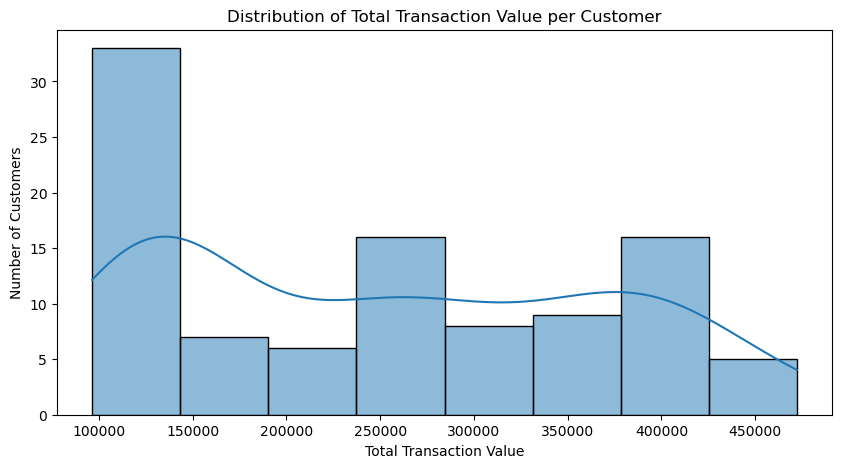

In [8]:
# Distribution of Total Transaction Value
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_stats["TotalTransactionValue"],
    kde=True
)

plt.title("Distribution of Total Transaction Value per Customer")
plt.xlabel("Total Transaction Value")
plt.ylabel("Number of Customers")
plt.show()

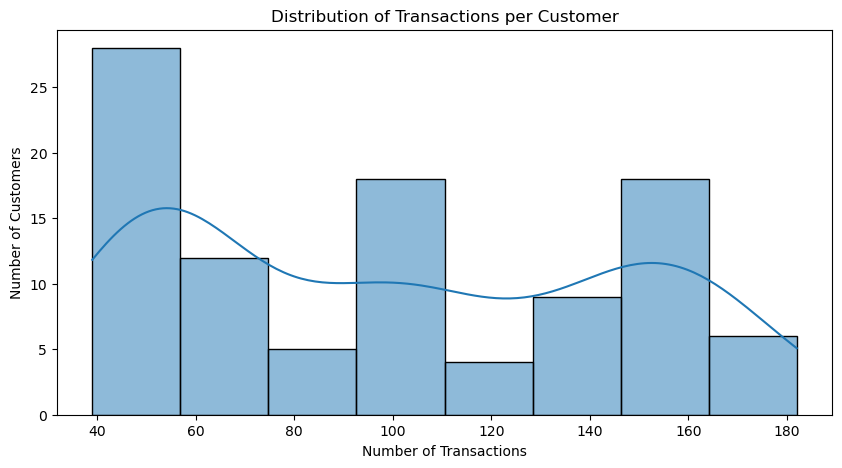

In [9]:
# Distribution of Transaction Count
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_stats["TransactionCount"],
    kde=True
)

plt.title("Distribution of Transactions per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.show()

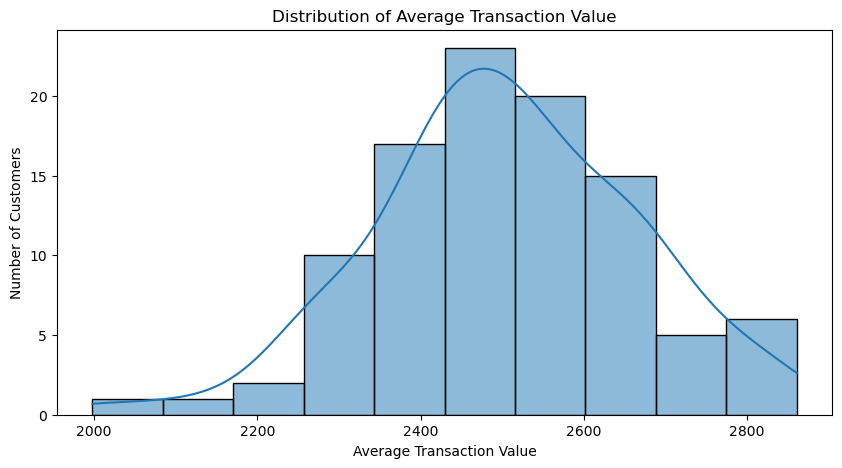

In [10]:
# Distribution of Average Transaction Value
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_stats["AverageTransactionValue"],
    kde=True
)

plt.title("Distribution of Average Transaction Value")
plt.xlabel("Average Transaction Value")
plt.ylabel("Number of Customers")
plt.show()

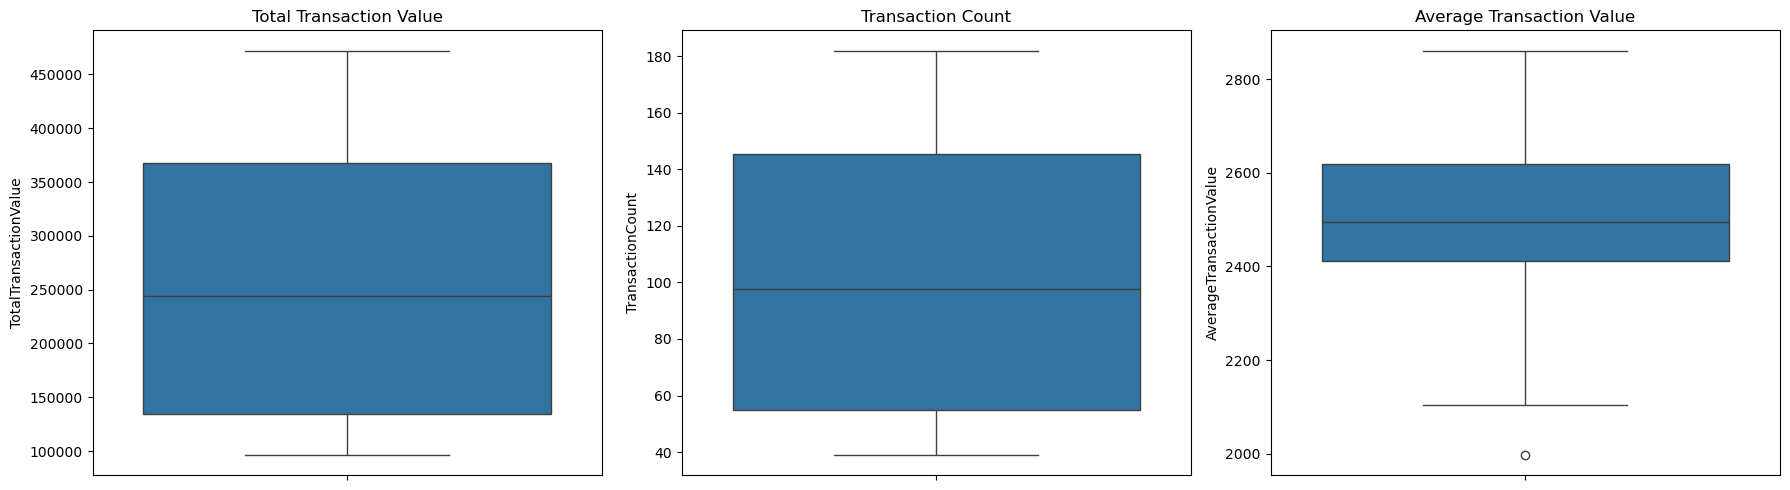

In [11]:
# Outlier Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    y=customer_stats["TotalTransactionValue"],
    ax=axes[0]
)
axes[0].set_title("Total Transaction Value")

sns.boxplot(
    y=customer_stats["TransactionCount"],
    ax=axes[1]
)
axes[1].set_title("Transaction Count")

sns.boxplot(
    y=customer_stats["AverageTransactionValue"],
    ax=axes[2]
)
axes[2].set_title("Average Transaction Value")

plt.tight_layout()
plt.show()

In [12]:
# Identify the actual outliers
metrics = [
    "TotalTransactionValue",
    "TransactionCount",
    "AverageTransactionValue"
]

for column in metrics:
    Q1 = customer_stats[column].quantile(0.25)
    Q3 = customer_stats[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = customer_stats[
        (customer_stats[column] < lower_bound) |
        (customer_stats[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outliers: {len(outliers)}")


TotalTransactionValue
Lower Bound: -215075.81
Upper Bound: 716667.32
Outliers: 0

TransactionCount
Lower Bound: -81.00
Upper Bound: 281.00
Outliers: 0

AverageTransactionValue
Lower Bound: 2097.81
Upper Bound: 2932.54
Outliers: 1


In [14]:
# Find the highest-value customers
customer_stats[
    [
        "CustomerID",
        "Age",
        "Region",
        "CustomerStatus",
        "TransactionCount",
        "TotalTransactionValue",
        "AverageTransactionValue"
    ]
].sort_values(
    "TotalTransactionValue",
    ascending=False
).head(10)

,CustomerID,Age,Region,CustomerStatus,TransactionCount,TotalTransactionValue,AverageTransactionValue
66,67,21.2,Utah,Inactive,174,472173.23,2713.639253
15,16,29.4,Colorado,Active,166,463014.76,2789.245542
45,46,50.8,Florida,Suspended,169,458802.04,2714.804970
57,58,57.3,Alaska,Active,180,458051.56,2544.730889
26,27,28.3,Alaska,Active,171,433565.88,2535.472982
93,94,37.6,Florida,Inactive,153,425100.06,2778.431765
40,41,23.4,Colorado,Inactive,156,417105.96,2673.756154
94,95,29.5,New Mexico,Inactive,182,415656.03,2283.824341
31,32,41.8,Kansas,Active,162,410286.68,2532.633827
95,96,48.9,Massachusetts,Active,160,404461.28,2527.883000


## **Business Insights**:

- **Total Transaction Value:** Customer-level transaction value ranges from approximately **95,000 to 470,000**. The IQR method identified **no outliers**, indicating that total transaction value is relatively consistent across customers.

- **Transaction Frequency:** Customers perform approximately **40 to 180 transactions**. No IQR-based outliers were detected, suggesting that transaction frequency is broadly distributed across the customer base without extreme activity levels.

- **Average Transaction Value:** Most customers have an average transaction value concentrated around **2,400–2,650**. One outlier was identified below the lower IQR boundary of **2,097.81**, indicating a customer with an unusually low average transaction value.

- **Distribution Pattern:** Total transaction value and transaction frequency show a relatively broad and uneven distribution, while average transaction value appears more concentrated around its central range.

- **Business Implication:** The absence of extreme outliers in total transaction value and transaction frequency suggests that the bank's overall customer activity is not dominated by a small number of exceptionally active customers. The identified low-value transaction customer should be investigated further to determine whether the behavior represents a genuine customer segment or an unusual pattern.

- **Next Step:** The identified outlier should **not be removed automatically**. In financial analysis, unusual customer behavior can be business-relevant. Further analysis should determine whether this customer has a distinct transaction pattern, account type, or channel preference.

# **3. Correlation Analysis:**

## Business Objective:

- **To identify the strength and direction of relationships between customer age, transaction frequency, total transaction value, and average transaction value. This analysis will help determine which customer characteristics and behavioral metrics are associated with higher financial activity.**

In [16]:
# corr data
correlation_data = customer_stats[
    [
        "Age",
        "TransactionCount",
        "TotalTransactionValue",
        "AverageTransactionValue"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,Age,TransactionCount,TotalTransactionValue,AverageTransactionValue
Age,1.00,-0.06,-0.06,0.07
TransactionCount,-0.06,1.00,0.99,0.06
TotalTransactionValue,-0.06,0.99,1.00,0.18
AverageTransactionValue,0.07,0.06,0.18,1.00


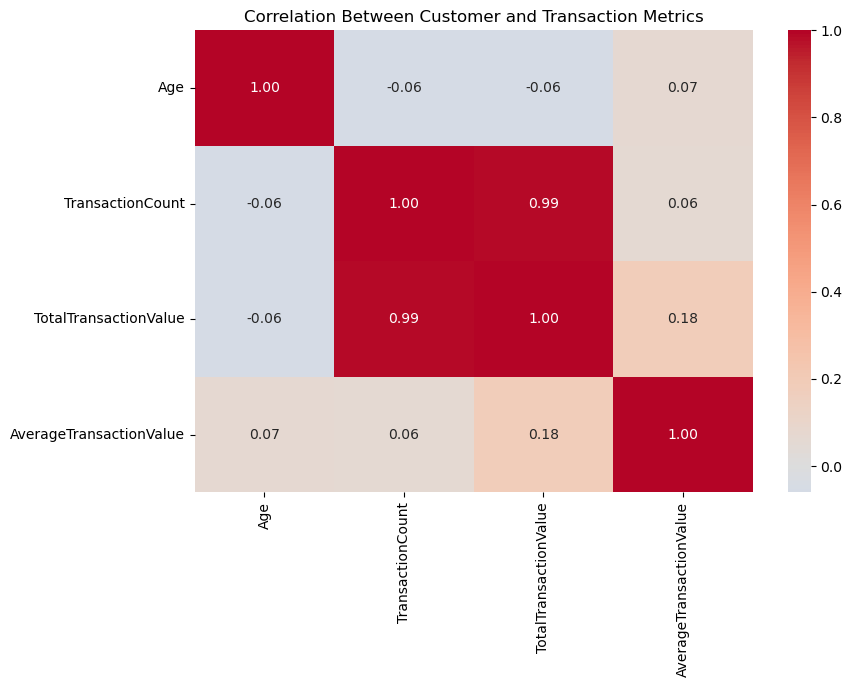

In [17]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Customer and Transaction Metrics")
plt.show()

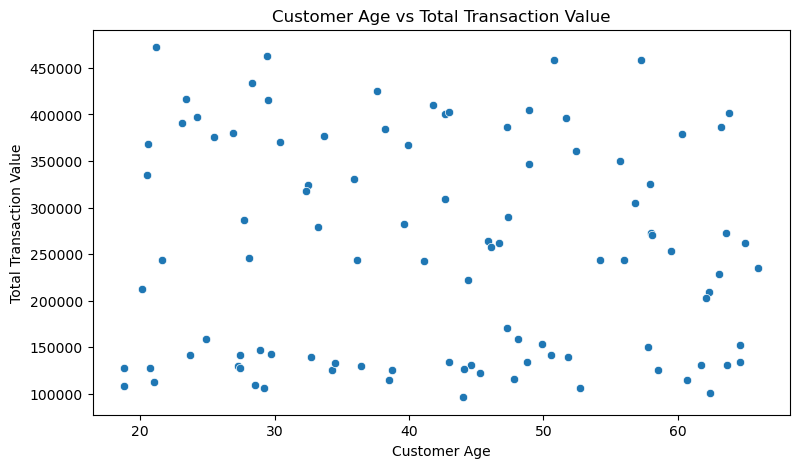

In [18]:
# Age vs Total Transaction Value
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=customer_stats,
    x="Age",
    y="TotalTransactionValue"
)

plt.title("Customer Age vs Total Transaction Value")
plt.xlabel("Customer Age")
plt.ylabel("Total Transaction Value")
plt.show()

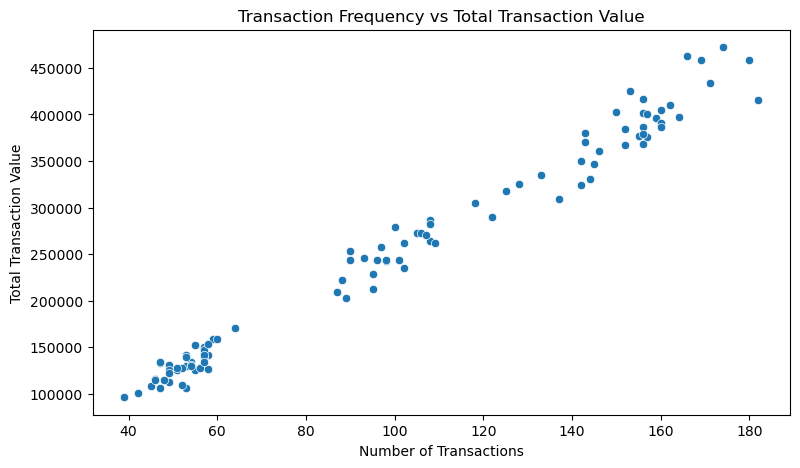

In [19]:
# Transaction Count vs Total Transaction Value
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=customer_stats,
    x="TransactionCount",
    y="TotalTransactionValue"
)

plt.title("Transaction Frequency vs Total Transaction Value")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Transaction Value")
plt.show()

In [20]:
# strongest relationships
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.round(2)

TransactionCount       TotalTransactionValue      0.99
TotalTransactionValue  AverageTransactionValue    0.18
Age                    AverageTransactionValue    0.07
                       TransactionCount          -0.06
TransactionCount       AverageTransactionValue    0.06
Age                    TotalTransactionValue     -0.06
dtype: float64

## **Business Insights:**

- **Transaction Frequency and Total Transaction Value:** Transaction count and total transaction value have an extremely strong positive correlation of **0.99**. This indicates that customers who perform more transactions tend to generate substantially higher total transaction values.

- **Customer Age and Transaction Activity:** Customer age has a very weak negative correlation with transaction count (**-0.06**) and total transaction value (**-0.06**). This suggests that age is not strongly associated with overall customer transaction activity.

- **Customer Age and Average Transaction Value:** Age has a very weak positive correlation of **0.07** with average transaction value, indicating little to no linear relationship between customer age and the typical value of their transactions.

- **Transaction Count and Average Transaction Value:** The correlation between transaction count and average transaction value is only **0.06**, suggesting that customers who transact more frequently do not necessarily make larger individual transactions.

- **Overall Finding:** Transaction frequency is strongly associated with total customer transaction value, while customer age has little relationship with financial activity. This suggests that **customer engagement and transaction frequency are more relevant indicators of overall transaction value than age**.

# **4. Hypothesis Testing:**

## **1. Independent T-Test:**

## Business Objective:

- **To determine whether the average transaction value differs significantly between Debit and Credit transactions. This analysis can help identify whether transaction type is associated with different levels of transaction value.**

### Hypotheses:

- **H₀ (Null Hypothesis):** The mean transaction value of Debit and Credit transactions is equal.
- **H₁ (Alternative Hypothesis):** The mean transaction value of Debit and Credit transactions is different.

**Significance Level (α):** 0.05

In [24]:
query = """
SELECT
    TransactionID,
    TransactionType,
    ABS(TransactionAmount) AS TransactionValue
FROM fact_transaction
"""

banking_data = pd.read_sql(text(query), engine)

print("Banking transaction data loaded successfully!")
print("Shape:", banking_data.shape)
banking_data.head()

Banking transaction data loaded successfully!
Shape: (10000, 3)


,TransactionID,TransactionType,TransactionValue
0,1,Credit,10000.00
1,2,Credit,10000.00
2,3,Debit,4883.80
3,4,Credit,3911.93
4,5,Credit,2211.72


In [25]:
from scipy.stats import ttest_ind
# Prepare the two groups
debit = banking_data[
    banking_data["TransactionType"] == "Debit"
]["TransactionValue"]

credit = banking_data[
    banking_data["TransactionType"] == "Credit"
]["TransactionValue"]

print("Debit Transactions:", len(debit))
print("Credit Transactions:", len(credit))

print("\nDebit Mean:", debit.mean())
print("Credit Mean:", credit.mean())

Debit Transactions: 6037
Credit Transactions: 3963

Debit Mean: 2505.0637833360943
Credit Mean: 2511.8648750946254


In [26]:
# Perform the T-Test
t_stat, p_value = ttest_ind(
    debit,
    credit,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.2325032892534782
P-value: 0.8161526839405387


In [27]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
    print("There is a statistically significant difference in mean transaction value.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant difference in mean transaction value.")

Fail to reject H₀
There is no statistically significant difference in mean transaction value.


In [29]:
print("STATISTICAL TEST RESULT")
print("=" * 40)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")


STATISTICAL TEST RESULT
T-statistic: -0.2325
P-value: 0.816153


## **Business Insights:**

- **Average Transaction Value:** Debit transactions have an average transaction value of **2,505.06**, while Credit transactions average **2,511.86**.

- **Statistical Significance:** The independent T-Test produced a **p-value of 0.8162**, which is substantially higher than the significance level of **0.05**. Therefore, there is no statistically significant difference between the mean transaction values of Debit and Credit transactions.

- **Business Interpretation:** Although Credit transactions have a slightly higher average transaction value, the difference of approximately **6.80** is too small to be considered statistically significant.

- **Conclusion:** Transaction type does not appear to have a meaningful effect on average transaction value in this dataset. The bank therefore does not have statistical evidence that Debit and Credit transactions generate different average transaction values.

## **2.One-Way ANOVA:**

## Business Objective:

- **To determine whether the average transaction value differs significantly across the bank's transaction channels: Mobile, Web, and ATM. This analysis will help identify whether the channel used by customers is associated with differences in transaction value.**

### Hypotheses:

- **H₀ (Null Hypothesis):** The mean transaction value is equal across Mobile, Web, and ATM channels.
- **H₁ (Alternative Hypothesis):** At least one transaction channel has a different mean transaction value.

**Significance Level (α):** 0.05

In [33]:
query = """
SELECT
    TransactionID,
    TransactionType,
    TransactionChannel,
    ABS(TransactionAmount) AS TransactionValue
FROM fact_transaction
"""

banking_data = pd.read_sql(text(query), engine)

print("Banking transaction data loaded successfully!")
print("Shape:", banking_data.shape)
print(banking_data.head())

Banking transaction data loaded successfully!
Shape: (10000, 4)
   TransactionID TransactionType TransactionChannel  TransactionValue
0              1          Credit                Web          10000.00
1              2          Credit                Web          10000.00
2              3           Debit                Web           4883.80
3              4          Credit                ATM           3911.93
4              5          Credit             Mobile           2211.72


In [34]:
from scipy.stats import f_oneway
# Prepare the groups
mobile = banking_data[
    banking_data["TransactionChannel"] == "Mobile"
]["TransactionValue"]

web = banking_data[
    banking_data["TransactionChannel"] == "Web"
]["TransactionValue"]

atm = banking_data[
    banking_data["TransactionChannel"] == "ATM"
]["TransactionValue"]

print("Mobile Transactions:", len(mobile))
print("Web Transactions:", len(web))
print("ATM Transactions:", len(atm))

print("\nMobile Mean:", mobile.mean())
print("Web Mean:", web.mean())
print("ATM Mean:", atm.mean())

Mobile Transactions: 5044
Web Transactions: 2990
ATM Transactions: 1966

Mobile Mean: 2516.937416732752
Web Mean: 2474.4856086956524
ATM Mean: 2534.81498474059


In [35]:
# Perform ANOVA
f_stat, p_value = f_oneway(
    mobile,
    web,
    atm
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.2554436624428165
P-value: 0.28499432030457933


In [36]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
    print("There is a statistically significant difference in mean transaction value across the channels.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant difference in mean transaction value across the channels.")

Fail to reject H₀
There is no statistically significant difference in mean transaction value across the channels.


In [37]:
print("STATISTICAL TEST RESULT")
print("=" * 40)
print(f"Mobile Mean: {mobile.mean():,.2f}")
print(f"Web Mean: {web.mean():,.2f}")
print(f"ATM Mean: {atm.mean():,.2f}")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

STATISTICAL TEST RESULT
Mobile Mean: 2,516.94
Web Mean: 2,474.49
ATM Mean: 2,534.81
F-statistic: 1.2554
P-value: 0.284994


## Business Insights

- **Channel Transaction Values:** The average transaction value was **2,516.94** for Mobile, **2,474.49** for Web, and **2,534.81** for ATM transactions. Although ATM transactions had the highest average and Web transactions had the lowest, the differences were relatively small.

- **Statistical Significance:** The One-Way ANOVA produced an **F-statistic of 1.2554** and a **p-value of 0.284994**. Since the p-value is greater than the significance level of **0.05**, we fail to reject the null hypothesis.

- **Business Interpretation:** There is **no statistically significant difference** in average transaction value across Mobile, Web, and ATM channels.

- **Conclusion:** The transaction channel does not appear to meaningfully influence the average value of individual transactions. Therefore, differences in transaction value across channels should not be treated as a statistically meaningful channel effect based on this dataset.

## **3.Chi-Square Test:**

## Business Objective:

- **To determine whether customer status is significantly associated with the transaction channel used by customers. This analysis will help identify whether Active, Inactive, and Suspended customers show different patterns in their use of Mobile, Web, and ATM transaction channels.**

### Hypotheses:

- **H₀ (Null Hypothesis):** Customer status and transaction channel are independent.
- **H₁ (Alternative Hypothesis):** Customer status and transaction channel are significantly associated.

**Significance Level (α):** 0.05

In [39]:
query = """
SELECT
    t.TransactionID,
    t.TransactionType,
    t.TransactionChannel,
    c.Status AS CustomerStatus,
    ABS(t.TransactionAmount) AS TransactionValue
FROM fact_transaction t
JOIN account a
    ON t.AccountID = a.AccountID
JOIN customer c
    ON a.CustomerID = c.CustomerID
"""

banking_data = pd.read_sql(text(query), engine)

print("Shape:", banking_data.shape)
banking_data.head()

Shape: (10000, 5)


,TransactionID,TransactionType,TransactionChannel,CustomerStatus,TransactionValue
0,1,Credit,Web,Suspended,10000.00
1,2,Credit,Web,Active,10000.00
2,3,Debit,Web,Inactive,4883.80
3,4,Credit,ATM,Active,3911.93
4,5,Credit,Mobile,Active,2211.72


In [41]:
# Create the contingency table
contingency_table = pd.crosstab(
    banking_data["CustomerStatus"],
    banking_data["TransactionChannel"]
)

contingency_table

TransactionChannel,ATM,Mobile,Web
CustomerStatus,,,
Active,730,1874,1165
Inactive,545,1405,765
Suspended,691,1765,1060


In [42]:
from scipy.stats import chi2_contingency
# chi-squared test
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 5.80322680273783
P-value: 0.21433324809101048
Degrees of freedom: 4


In [43]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
    print("There is a statistically significant association between customer status and transaction channel.")
else:
    print("Fail to reject H₀")
    print("There is no statistically significant association between customer status and transaction channel.")

Fail to reject H₀
There is no statistically significant association between customer status and transaction channel.


In [44]:
print("STATISTICAL TEST RESULT")
print("=" * 40)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

STATISTICAL TEST RESULT
Chi-square statistic: 5.8032
P-value: 0.214333
Degrees of freedom: 4


## Business Insights

- **Transaction Channel Distribution:** Active, Inactive, and Suspended customers all use Mobile, Web, and ATM channels, with Mobile being the most frequently used channel across all three customer-status groups.

- **Statistical Significance:** The Chi-Square test produced a **p-value of 0.214333**, which is greater than the significance level of **0.05**. Therefore, there is no statistically significant association between customer status and transaction channel.

- **Business Interpretation:** The observed differences in channel usage across Active, Inactive, and Suspended customers are not large enough to conclude that customer status influences transaction channel preference.

- **Conclusion:** Customer status and transaction channel appear to be statistically independent in this dataset. The bank can therefore avoid assuming that different customer-status groups require fundamentally different channel preferences based solely on this analysis.

## Key Statistical Findings

- **Customer Profile:** The average customer age is **42.38 years**, with a median of **43 years**, indicating a customer base concentrated around the early 40s.

- **Transaction Activity:** Customers perform an average of **100 transactions**, with a median of **97.5 transactions**, suggesting relatively consistent transaction activity across customers.

- **Transaction Value:** The average total transaction value per customer is **250,775.91**, compared with a median of **244,094.47**. The relatively close values indicate that transaction value is reasonably consistent across customers.

- **Outlier Analysis:** No IQR-based outliers were identified for total transaction value or transaction count. However, **one outlier** was identified for average transaction value, representing a customer with an unusually low average transaction value.

- **Correlation Analysis:** Transaction count has an extremely strong positive correlation (**0.99**) with total transaction value. This indicates that customers with more transactions tend to generate higher total transaction values. Customer age showed negligible correlation with transaction activity.

- **Debit vs Credit:** The Independent T-Test produced a **p-value of 0.8162**, indicating no statistically significant difference between the mean transaction values of Debit and Credit transactions.

- **Transaction Channels:** The One-Way ANOVA produced a **p-value of 0.2850**, indicating no statistically significant difference in average transaction value across Mobile, Web, and ATM channels.

- **Customer Status and Channel:** The Chi-Square test produced a **p-value of 0.2143**, indicating no statistically significant association between customer status and transaction channel.

- **Overall Finding:** The statistical analysis suggests that transaction value is primarily associated with transaction frequency, while customer age, transaction type, transaction channel, and customer status do not show statistically significant differences or relationships with the tested transaction metrics.